In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
STAT_PATH = "../experiments"
GRID_UTILIZATION_NAME = os.path.join("exp", "grid_utilization")
EXP_NAME = "run_"


In [3]:
def read_grid_utilization(file_path):
    df = pd.read_csv(file_path, header=None, names=["grid_utilization"])
    df["time_hours"] = df.index / 3600.0
    return df


def plot_grid_utilization(ax, df, label):
    ax.plot(df["time_hours"], df["grid_utilization"], label=label)
    ax.set_title("Grid utilization")
    ax.set_xlabel("Time, hours")
    ax.set_ylabel("Grid utilization")
    ax.set_ylim(0, 1)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


found ['run_0001']


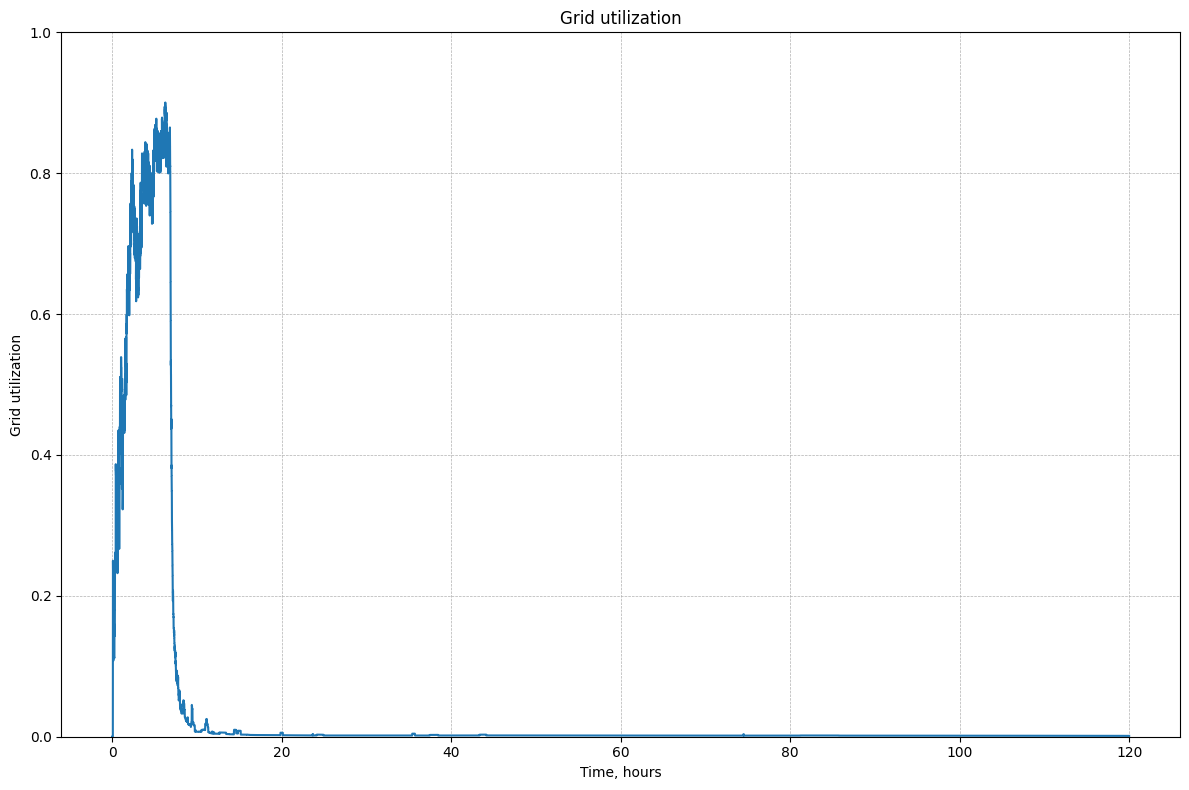

In [4]:
folders = sorted(
    folder
    for folder in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, folder)) and folder.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

datasets = []

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    grid_utilization_path = os.path.join(full_path, GRID_UTILIZATION_NAME)

    if not os.path.exists(grid_utilization_path):
        print(f"skip {folder}: {GRID_UTILIZATION_NAME} not found")
        continue

    datasets.append((folder, read_grid_utilization(grid_utilization_path)))

if not datasets:
    print("there is no grid utilization data to plot")
else:
    fig, ax = plt.subplots(figsize=(12, 8))

    for label, df in datasets:
        plot_grid_utilization(ax, df, label)

    if len(datasets) > 1:
        ax.legend()

    plt.tight_layout()
    plt.show()
